11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.8080 - loss: 0.6604 - val_accuracy: 0.9480 - val_loss: 0.1832
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9525 - loss: 0.1632 - val_accuracy: 0.9595 - val_loss: 0.1403
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9678 - loss: 0.1067 - val_accuracy: 0.9660 - val_loss: 0.1156
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9765 - loss: 0.0858 - val_accuracy: 0.9694 - val_loss: 0.1023
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9814 - loss: 0.0631 - val_accuracy: 0.9710 - val_loss: 0.0994
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9848 - loss: 0.0495 - val_accuracy: 0.9730 - val_loss: 0.0904
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9889 - loss: 0.0386 - val_accuracy: 0.9758 - val_loss: 0.0861
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9915 - loss: 0.0309 - val_accuracy: 0

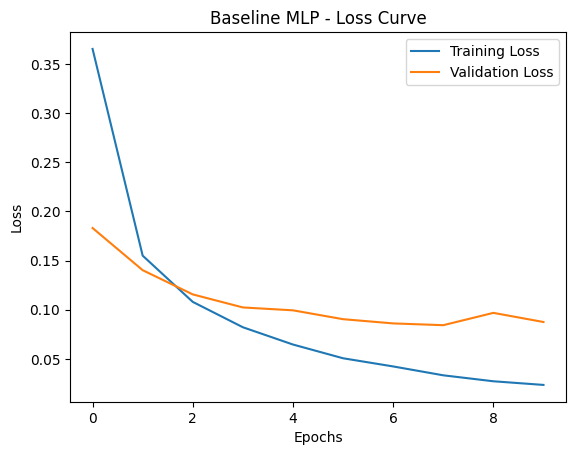

In [1]:
#SIMPLE MLP WITHOUT REGULARIZATION

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# -----------------------------
# Load MNIST Dataset
# -----------------------------
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize pixel values
X_train = X_train / 255.0
X_test = X_test / 255.0

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# -----------------------------
# Build MLP Model (No Regularization)
# -----------------------------
model = Sequential()
model.add(Flatten(input_shape=(28, 28)))
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))

# -----------------------------
# Compile Model
# -----------------------------
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# -----------------------------
# Train Model
# -----------------------------
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2
)

# -----------------------------
# Evaluate Model
# -----------------------------
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)


# -----------------------------
# Plot Loss Curve
# -----------------------------
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Baseline MLP - Loss Curve')
plt.show()

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.5897 - loss: 1.2359 - val_accuracy: 0.9287 - val_loss: 0.2480
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8784 - loss: 0.4191 - val_accuracy: 0.9463 - val_loss: 0.1885
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9054 - loss: 0.3389 - val_accuracy: 0.9560 - val_loss: 0.1591
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9170 - loss: 0.2976 - val_accuracy: 0.9591 - val_loss: 0.1485
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9254 - loss: 0.2618 - val_accuracy: 0.9620 - val_loss: 0.1385
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9323 - loss: 0.2400 - val_accuracy: 0.9630 - val_loss: 0.1294
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9337 - loss: 0.2266 - val_accuracy: 0.9654 - val_loss: 0.1259
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9399 - loss: 0.2087 - val_accuracy: 0.

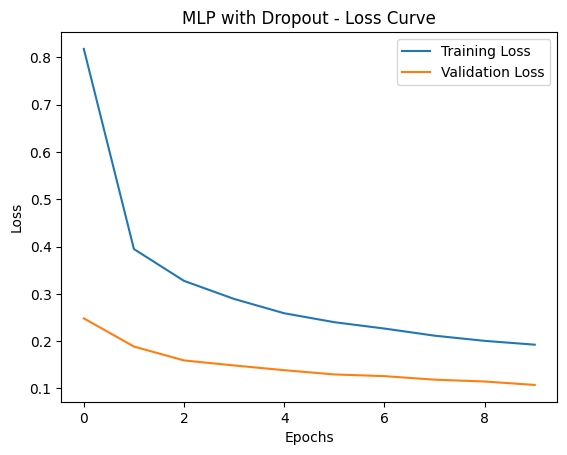

In [2]:
#Dropout

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# -----------------------------
# Load MNIST Dataset
# -----------------------------
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize pixel values
X_train = X_train / 255.0
X_test = X_test / 255.0

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# -----------------------------
# Build MLP Model (With Dropout)
# -----------------------------
model = Sequential()
model.add(Flatten(input_shape=(28, 28)))

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))          # Dropout layer

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))          # Dropout layer

model.add(Dense(10, activation='softmax'))

# -----------------------------
# Compile Model
# -----------------------------
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# -----------------------------
# Train Model
# -----------------------------
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2
)

# -----------------------------
# Evaluate Model
# -----------------------------
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)

# -----------------------------
# Plot Loss Curve
# -----------------------------
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('MLP with Dropout - Loss Curve')
plt.show()

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8111 - loss: 0.9055 - val_accuracy: 0.9492 - val_loss: 0.3544
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9458 - loss: 0.3428 - val_accuracy: 0.9578 - val_loss: 0.2923
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9586 - loss: 0.2807 - val_accuracy: 0.9622 - val_loss: 0.2596
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9659 - loss: 0.2441 - val_accuracy: 0.9660 - val_loss: 0.2336
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9725 - loss: 0.2151 - val_accuracy: 0.9679 - val_loss: 0.2162
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9759 - loss: 0.1954 - val_accuracy: 0.9693 - val_loss: 0.2079
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9769 - loss: 0.1826 - val_accuracy: 0.9653 - val_loss: 0.2105
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9783 - loss: 0.1722 - val_accuracy: 0.

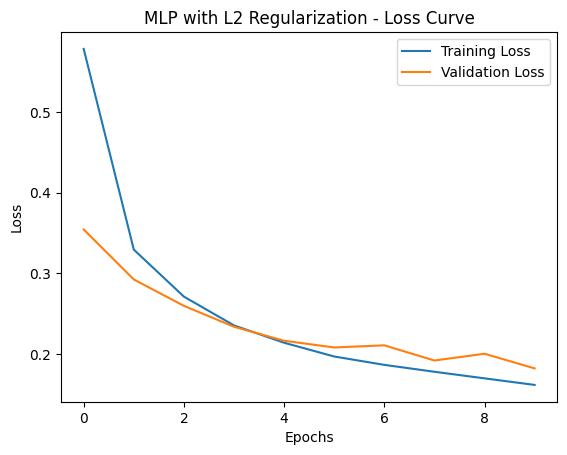

In [3]:
#L2 Regularization

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2

# -----------------------------
# Load MNIST Dataset
# -----------------------------
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize pixel values
X_train = X_train / 255.0
X_test = X_test / 255.0

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# -----------------------------
# Build MLP Model (With L2 Regularization)
# -----------------------------
model = Sequential()
model.add(Flatten(input_shape=(28, 28)))

model.add(Dense(128, activation='relu',
                kernel_regularizer=l2(0.001)))   # L2 applied

model.add(Dense(64, activation='relu',
                kernel_regularizer=l2(0.001)))   # L2 applied

model.add(Dense(10, activation='softmax'))

# -----------------------------
# Compile Model
# -----------------------------
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# -----------------------------
# Train Model
# -----------------------------
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2
)

# -----------------------------
# Evaluate Model
# -----------------------------
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)

# -----------------------------
# Plot Loss Curve
# -----------------------------
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('MLP with L2 Regularization - Loss Curve')
plt.show()

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8231 - loss: 0.6216 - val_accuracy: 0.9584 - val_loss: 0.1534
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9679 - loss: 0.1190 - val_accuracy: 0.9678 - val_loss: 0.1099
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9784 - loss: 0.0769 - val_accuracy: 0.9727 - val_loss: 0.0935
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9861 - loss: 0.0503 - val_accuracy: 0.9703 - val_loss: 0.0973
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9901 - loss: 0.0366 - val_accuracy: 0.9704 - val_loss: 0.0944
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9915 - loss: 0.0301 - val_accuracy: 0.9696 - val_loss: 0.1055
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9929 - loss: 0.0236 - val_accuracy: 0.9767 - val_loss: 0.0833
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9948 - loss: 0.0183 - val_accuracy: 0

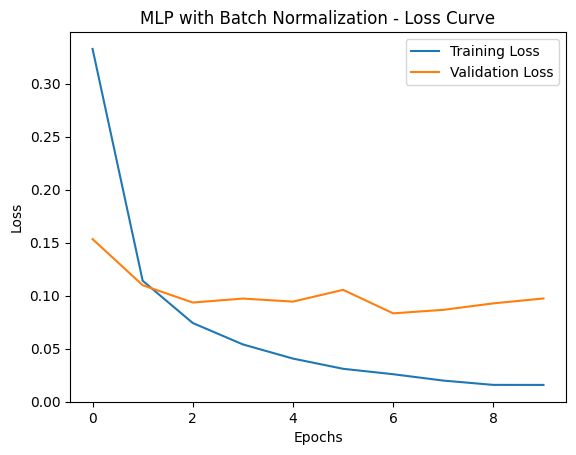

In [4]:
#Batch Normalization

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, BatchNormalization
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# -----------------------------
# Load MNIST Dataset
# -----------------------------
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize pixel values
X_train = X_train / 255.0
X_test = X_test / 255.0

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# -----------------------------
# Build MLP Model (With Batch Normalization)
# -----------------------------
model = Sequential()
model.add(Flatten(input_shape=(28, 28)))

model.add(Dense(128))
model.add(BatchNormalization())   # Batch Norm
model.add(tf.keras.layers.Activation('relu'))

model.add(Dense(64))
model.add(BatchNormalization())   # Batch Norm
model.add(tf.keras.layers.Activation('relu'))

model.add(Dense(10, activation='softmax'))

# -----------------------------
# Compile Model
# -----------------------------
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# -----------------------------
# Train Model
# -----------------------------
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2
)

# -----------------------------
# Evaluate Model
# -----------------------------
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)

# -----------------------------
# Plot Loss Curve
# -----------------------------
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('MLP with Batch Normalization - Loss Curve')
plt.show()